In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def _find_project_root() -> Path:
    current = Path.cwd()

    while current != current.parent:
        if (current / "src").is_dir():
            return current

        current = current.parent

    raise RuntimeError("Could not locate the project root (missing src/ directory).")


PROJECT_ROOT = _find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config_loader import get_paths  # noqa: E402

# Resolve configured paths against the project root so the notebook
# works regardless of the kernel working directory.
raw_paths = get_paths()["paths"]

paths = {
    key: (value if Path(value).is_absolute() else str(PROJECT_ROOT / value))
    for key, value in raw_paths.items()
}

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
events = pd.read_parquet(paths["browser_ram_categorized"])

print(f"Shape: {events.shape}")
events.head()

Shape: (25917, 10)


,timestamp,url,title,domain,visit_count,total_mb,used_mb,available_mb,usage_percent,category
0,2026-05-10 07:57:45.724093+00:00,https://www.instagram.com/p/DWbzENEkoXZ/?chain...,Motivation | Masculinity | Wisdom | 🇯🇵この速度に達する...,www.instagram.com,1,8192,3139.88,5052.12,38.33,Social Media
1,2026-05-10 07:58:01.129075+00:00,https://www.instagram.com/explore/,Instagram,www.instagram.com,395,8192,3348.61,4843.39,40.88,Social Media
2,2026-05-10 07:58:23.218971+00:00,https://www.instagram.com/explore/,Instagram,www.instagram.com,395,8192,2937.28,5254.72,35.86,Social Media
3,2026-05-10 07:58:24.793832+00:00,https://www.instagram.com/explore/search/,Instagram,www.instagram.com,57,8192,3035.53,5156.47,37.05,Social Media
4,2026-05-10 07:58:39.156316+00:00,https://www.instagram.com/explore/search/keywo...,#fedorahats • Instagram,www.instagram.com,1,8192,3296.28,4895.72,40.24,Social Media


In [3]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 25917 entries, 0 to 25916
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   timestamp      25917 non-null  datetime64[us, UTC]
 1   url            25917 non-null  str                
 2   title          25917 non-null  str                
 3   domain         25916 non-null  str                
 4   visit_count    25917 non-null  int64              
 5   total_mb       25917 non-null  int64              
 6   used_mb        25917 non-null  float64            
 7   available_mb   25917 non-null  float64            
 8   usage_percent  25917 non-null  float64            
 9   category       25917 non-null  string             
dtypes: datetime64[us, UTC](1), float64(3), int64(2), str(3), string(1)
memory usage: 14.5 MB


In [4]:
events = events.copy()

events["timestamp"] = pd.to_datetime(
    events["timestamp"],
    utc=True,
)

events["hour"] = events["timestamp"].dt.hour
events["day_of_week"] = events["timestamp"].dt.day_name()
events["date"] = events["timestamp"].dt.date
events["day_of_week_num"] = events["timestamp"].dt.dayofweek

# Temporal Distribution

In [5]:
# Browsing activity by hour of the day.
hourly_activity = events.groupby("hour").size().reindex(range(24), fill_value=0)

hourly_activity

hour
0      192
1      690
2     1902
3     1131
4     1355
5     1341
6     1106
7     1316
8     1811
9     1598
10    1940
11    2286
12    1321
13    1693
14    1360
15    1422
16    1503
17    1245
18     537
19     108
20       0
21       5
22      12
23      43
dtype: int64

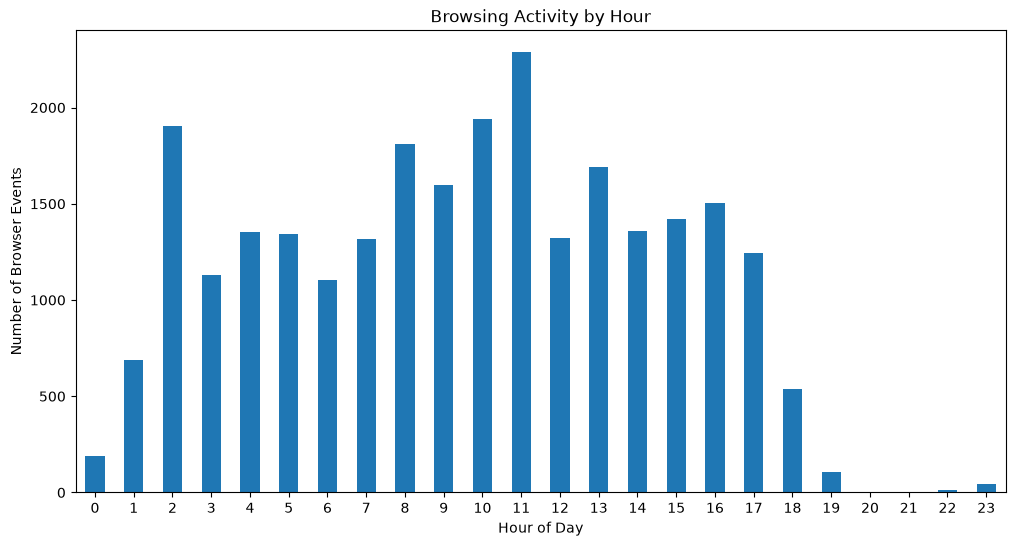

In [6]:
plt.figure(figsize=(12, 6))

hourly_activity.plot(kind="bar")

plt.title("Browsing Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Browser Events")
plt.xticks(rotation=0)

plt.show()

In [7]:
# Browsing activity by day of the week.
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

daily_week_activity = events.groupby("day_of_week").size().reindex(day_order)

daily_week_activity

day_of_week
Monday       3774
Tuesday      4014
Wednesday    3997
Thursday     4102
Friday       2989
Saturday     3089
Sunday       3952
dtype: int64

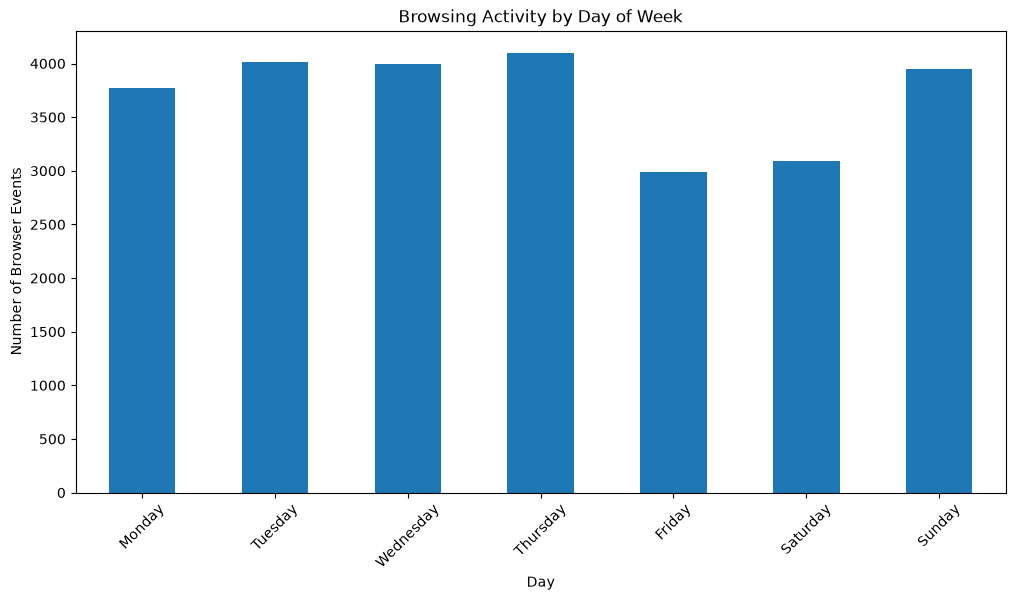

In [8]:
plt.figure(figsize=(12, 6))

daily_week_activity.plot(kind="bar")

plt.title("Browsing Activity by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Browser Events")
plt.xticks(rotation=45)

plt.show()

In [9]:
# Daily browsing activity.
daily_activity = events.groupby("date").size()

daily_activity

date
2026-05-10     435
2026-05-11     423
2026-05-12      41
2026-05-13     151
2026-05-14     129
2026-05-15     107
2026-05-16     135
2026-05-17     242
2026-05-18     580
2026-05-19    1491
2026-05-20     739
2026-05-21     366
2026-05-22      66
2026-05-24     209
2026-05-25     221
2026-05-26      27
2026-05-27     322
2026-05-28     106
2026-05-29      89
2026-05-30      62
2026-05-31      98
2026-06-01      64
2026-06-02     200
2026-06-03     227
2026-06-04     337
2026-06-05     299
2026-06-06     131
2026-06-07      49
2026-06-08     224
2026-06-09     203
2026-06-10      58
2026-06-11     156
2026-06-12      51
2026-06-13      30
2026-06-14       3
2026-06-15      30
2026-06-16      84
2026-06-17       6
2026-06-18      79
2026-06-19     122
2026-06-20     168
2026-06-21     144
2026-06-22     134
2026-06-23     125
2026-06-24      10
2026-06-25     161
2026-06-26      68
2026-06-27     164
2026-06-28     123
2026-06-29     149
2026-06-30     324
2026-07-01     538
2026-07

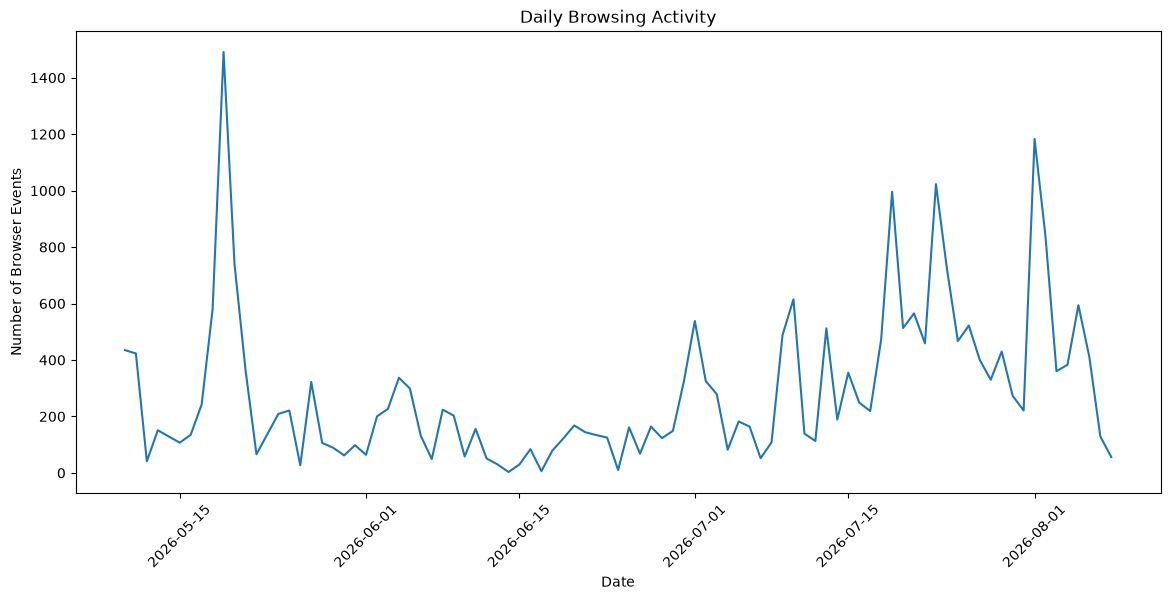

In [10]:
plt.figure(figsize=(14, 6))

daily_activity.plot()

plt.title("Daily Browsing Activity")
plt.xlabel("Date")
plt.ylabel("Number of Browser Events")
plt.xticks(rotation=45)

plt.show()

# Browser Behaviour

In [11]:
# Most visited domains by number of events.
domain_counts = events["domain"].dropna().value_counts()

domain_counts.head(20)

domain
www.google.com                            11308
www.instagram.com                          3292
colab.research.google.com                  2384
m.youtube.com                               861
github.com                                  590
accounts.google.com                         535
www.youtube.com                             398
docs.google.com                             299
www.linkedin.com                            271
drive.google.com                            242
www.guvi.in                                 195
careerzenith.ai                             189
mail.google.com                             153
learn.microsoft.com                         146
chatgpt.com                                 139
www.canva.com                               134
propelld.com                                134
dbc-769439ff-d9f3.cloud.databricks.com      133
www.flipkart.com                             94
www.databricks.com                           92
Name: count, dtype: int64

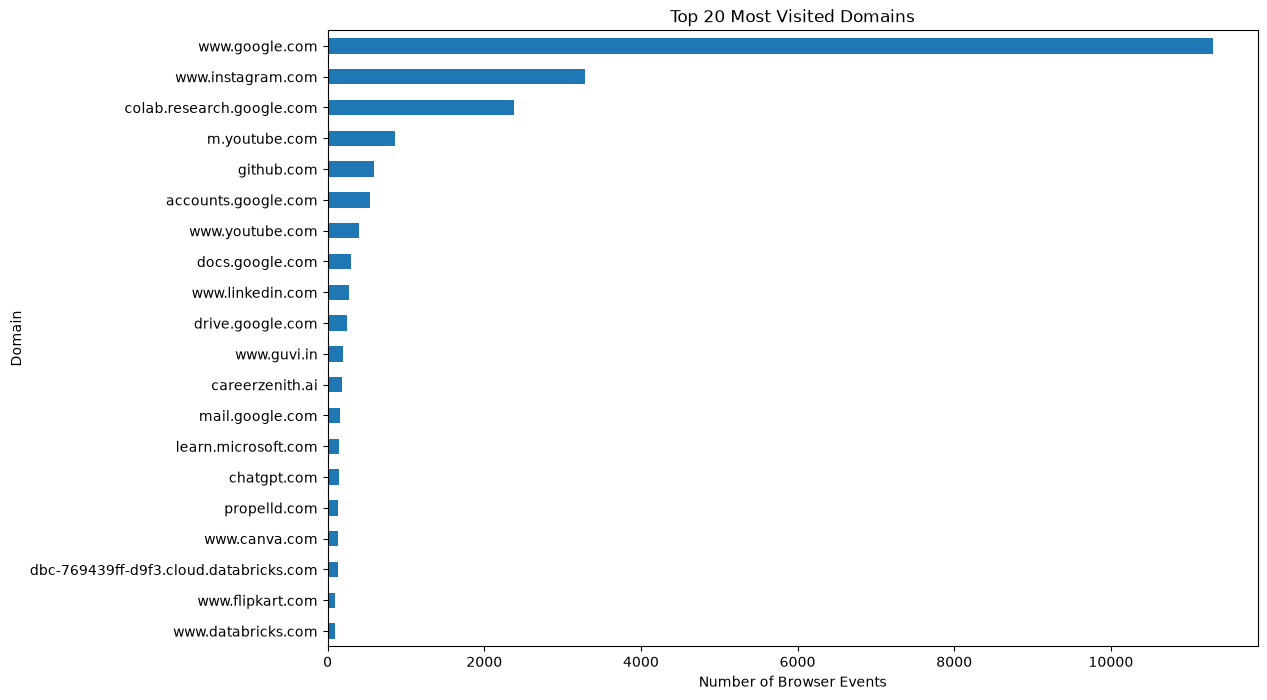

In [12]:
top_domains = domain_counts.head(20).sort_values()

plt.figure(figsize=(12, 8))

top_domains.plot(kind="barh")

plt.title("Top 20 Most Visited Domains")
plt.xlabel("Number of Browser Events")
plt.ylabel("Domain")

plt.show()

In [13]:
# Visit frequency per domain.
#
# NOTE: visit_count is a cumulative per-URL counter in Chrome history,
# so summing it across URLs produces meaningless totals. We therefore
# report the number of recorded events and unique URLs per domain.
visit_frequency = (
    events.groupby("domain")
    .agg(
        visits=("domain", "size"),
        unique_urls=("url", "nunique"),
    )
    .sort_values("visits", ascending=False)
)

visit_frequency.head(20)

,visits,unique_urls
domain,,
www.google.com,11308,7163
www.instagram.com,3292,1123
colab.research.google.com,2384,350
m.youtube.com,861,479
github.com,590,251
accounts.google.com,535,504
www.youtube.com,398,196
docs.google.com,299,102
www.linkedin.com,271,128


In [14]:
print(f"Unique domains: {events['domain'].nunique():,}")
print(f"Unique URLs: {events['url'].nunique():,}")
print(f"Unique page titles: {events['title'].nunique():,}")

Unique domains: 664
Unique URLs: 13,267
Unique page titles: 4,377


In [15]:
# Repeated visit analysis.
url_frequency = events["url"].value_counts()

single_visit_urls = int((url_frequency == 1).sum())
repeated_visit_urls = int((url_frequency > 1).sum())
repeated_percentage = repeated_visit_urls / len(url_frequency) * 100

print(f"Unique URLs: {len(url_frequency):,}")
print(f"URLs visited once: {single_visit_urls:,}")
print(f"URLs visited multiple times: {repeated_visit_urls:,}")
print(f"Repeated URL percentage: {repeated_percentage:.2f}%")

url_frequency.head(20)

Unique URLs: 13,267
URLs visited once: 9,017
URLs visited multiple times: 4,250
Repeated URL percentage: 32.03%


url
https://www.instagram.com/explore/                                                                            425
https://www.instagram.com/direct/inbox/                                                                       269
https://www.instagram.com/                                                                                    265
https://m.youtube.com/                                                                                        166
https://www.instagram.com/direct/t/1683823392972925/                                                           97
https://www.youtube.com/                                                                                       89
https://drive.google.com/drive/u/0/my-drive                                                                    74
https://www.linkedin.com/in/abish3k-murugan/                                                                   66
https://www.instagram.com/explore/search/                                           

# Category Analysis

In [16]:
# Event share by behavioral category.
category_counts = events["category"].value_counts()

category_share = category_counts / category_counts.sum() * 100

pd.DataFrame(
    {
        "events": category_counts,
        "share_percent": category_share.round(2),
    }
)

,events,share_percent
category,,
Search/Reference,12415,47.9
Social Media,4935,19.04
Learning/Education,4009,15.47
Productivity/Work,2155,8.32
Shopping,536,2.07
Other,462,1.78
Job Search/Career,323,1.25
Ads/Suspicious Redirects,249,0.96
Piracy/Streaming (Unofficial),194,0.75


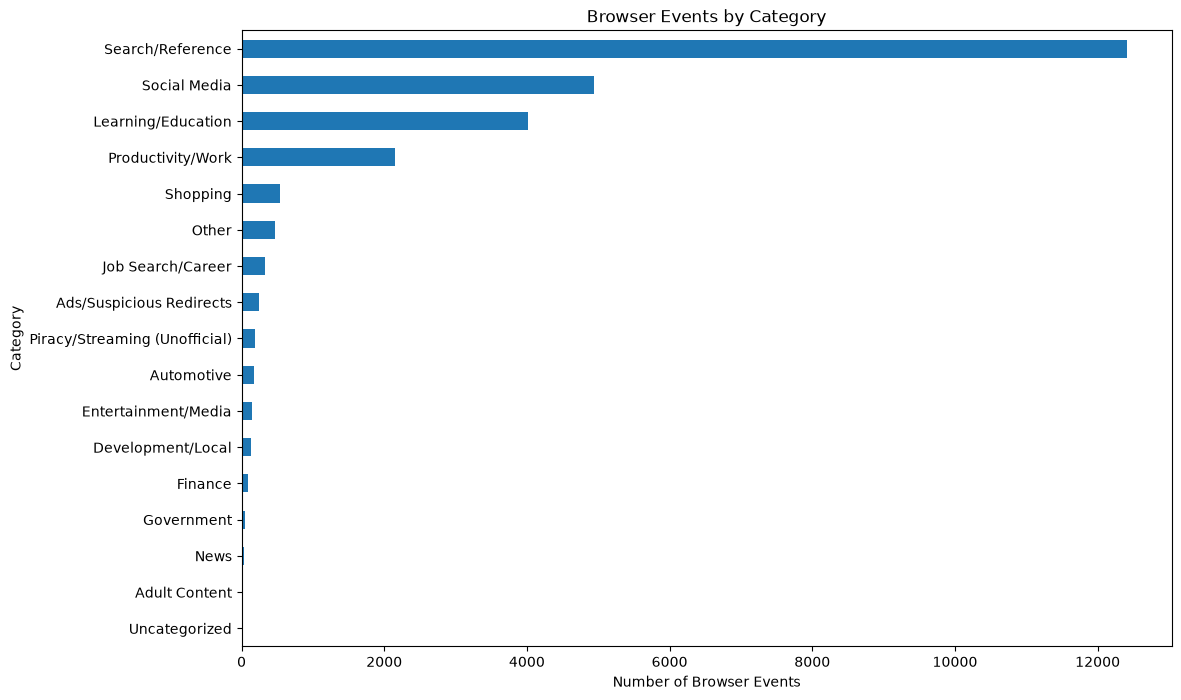

In [17]:
plt.figure(figsize=(12, 8))

category_counts.sort_values().plot(kind="barh")

plt.title("Browser Events by Category")
plt.xlabel("Number of Browser Events")
plt.ylabel("Category")

plt.show()

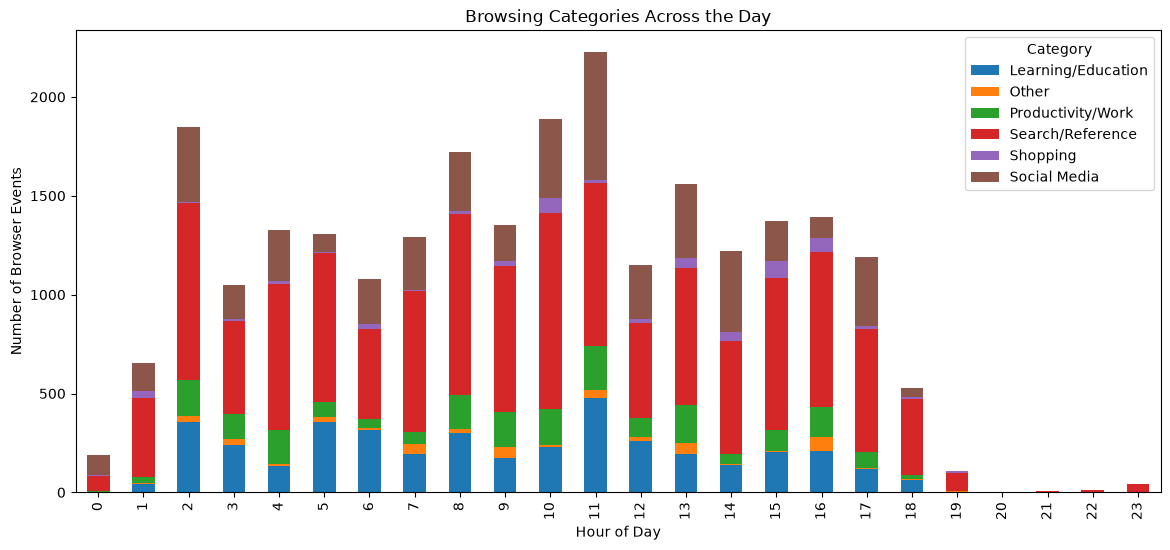

In [18]:
# Top categories across the day.
top_categories = category_counts.head(6).index

category_by_hour = (
    events[events["category"].isin(top_categories)]
    .pivot_table(
        index="hour",
        columns="category",
        values="timestamp",
        aggfunc="count",
    )
    .reindex(range(24), fill_value=0)
    .fillna(0)
    .astype(int)
)

category_by_hour.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
)

plt.title("Browsing Categories Across the Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Browser Events")
plt.legend(title="Category")

plt.show()

In [19]:
# RAM usage during browsing by category.
ram_by_category = (
    events.groupby("category")
    .agg(
        avg=("usage_percent", "mean"),
        median=("usage_percent", "median"),
        max=("usage_percent", "max"),
        events=("usage_percent", "size"),
    )
    .sort_values("avg", ascending=False)
)

ram_by_category

,avg,median,max,events
category,,,,
News,48.446364,49.660,57.58,33
Automotive,45.787500,46.350,56.14,176
Shopping,44.817743,44.970,62.15,536
Social Media,43.171048,42.990,61.17,4935
Entertainment/Media,43.067500,43.740,56.04,148
Finance,42.834318,41.930,55.47,88
Development/Local,41.994148,42.620,56.60,135
Search/Reference,41.982756,41.440,65.22,12415
Job Search/Career,41.949040,42.220,59.29,323


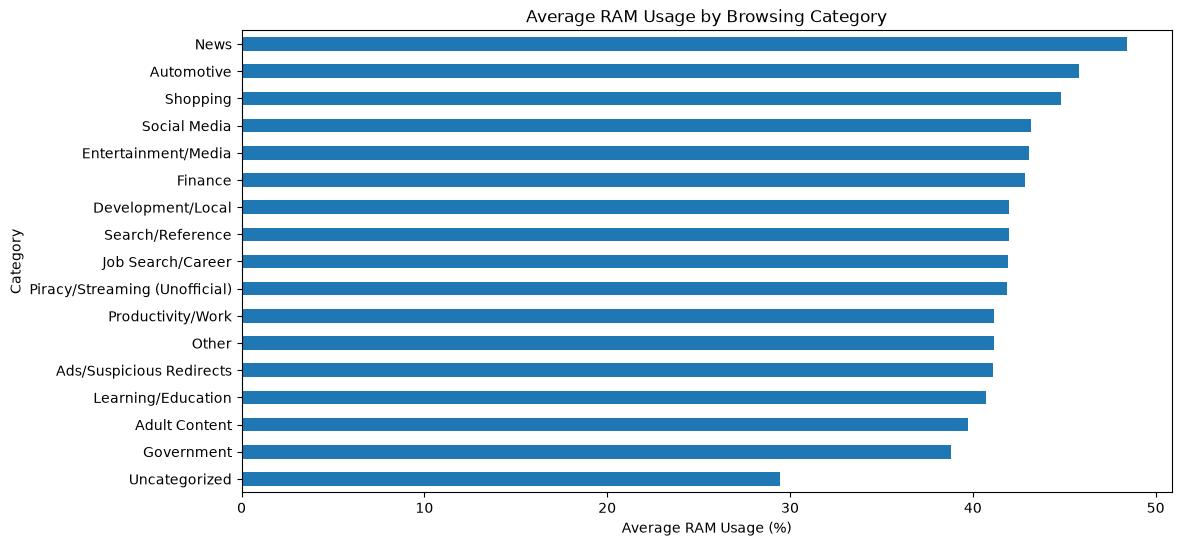

In [20]:
plt.figure(figsize=(12, 6))

ram_by_category["avg"].sort_values().plot(kind="barh")

plt.title("Average RAM Usage by Browsing Category")
plt.xlabel("Average RAM Usage (%)")
plt.ylabel("Category")

plt.show()

# RAM Relationship

In [21]:
events["usage_percent"].describe()

count    25917.000000
mean        42.012783
std          6.739810
min         20.550000
25%         37.120000
50%         41.660000
75%         46.830000
max         65.220000
Name: usage_percent, dtype: float64

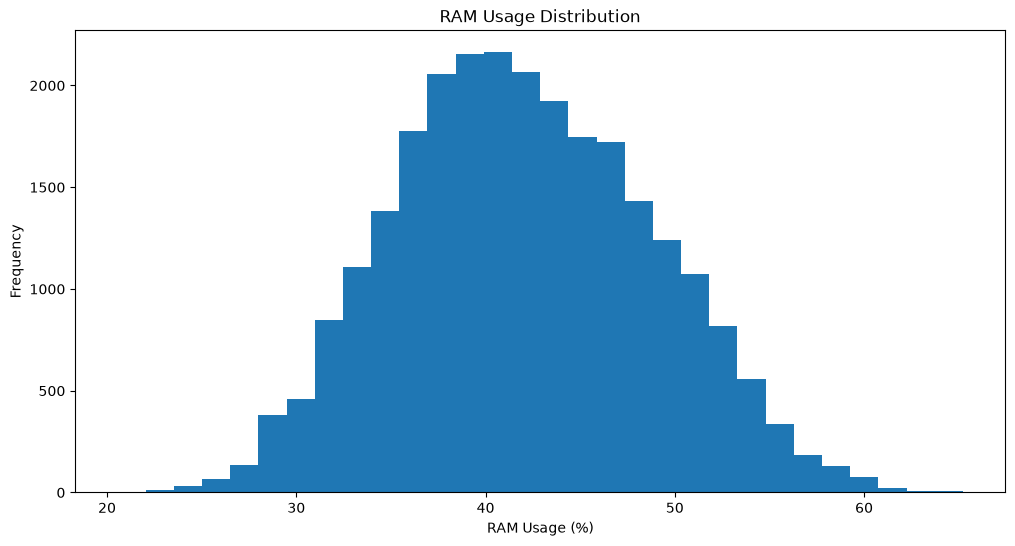

In [22]:
plt.figure(figsize=(12, 6))

events["usage_percent"].plot(
    kind="hist",
    bins=30,
)

plt.title("RAM Usage Distribution")
plt.xlabel("RAM Usage (%)")
plt.ylabel("Frequency")

plt.show()

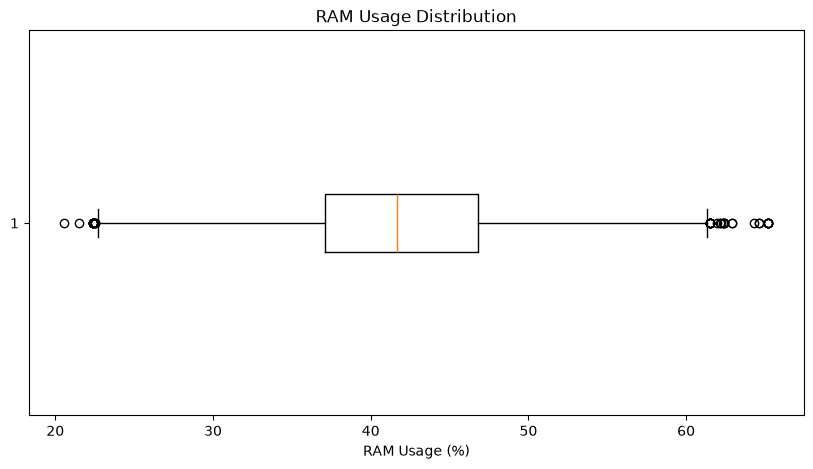

In [23]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    events["usage_percent"].dropna(),
    orientation="horizontal",
)

plt.title("RAM Usage Distribution")
plt.xlabel("RAM Usage (%)")

plt.show()

In [24]:
# RAM usage during browsing activity.
events[["used_mb", "available_mb", "usage_percent"]].describe()

,used_mb,available_mb,usage_percent
count,25917.000000,25917.000000,25917.000000
mean,3441.686815,4750.313185,42.012783
std,552.128312,552.128312,6.739810
min,1683.700000,2849.400000,20.550000
25%,3041.060000,4356.010000,37.120000
50%,3412.620000,4779.380000,41.660000
75%,3835.990000,5150.940000,46.830000
max,5342.600000,6508.300000,65.220000


In [25]:
ram_by_hour = (
    events.groupby("hour")["usage_percent"]
    .agg(
        mean="mean",
        median="median",
        min="min",
        max="max",
    )
    .reindex(range(24))
)

ram_by_hour

,mean,median,min,max
hour,,,,
0,40.772083,41.445,26.68,49.81
1,40.186826,40.160,28.06,52.63
2,37.659111,37.675,24.81,53.07
3,36.774633,37.020,23.36,54.43
4,36.210524,36.270,20.55,49.52
5,35.766465,35.710,22.42,51.57
6,36.626230,36.470,23.82,48.76
7,36.963533,37.010,23.85,49.13
8,37.575146,37.550,23.68,50.38


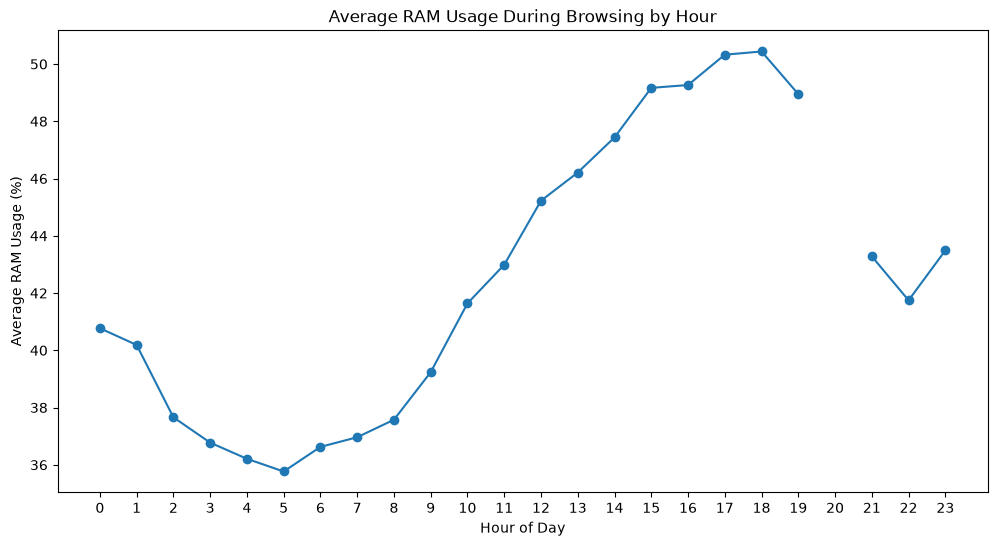

In [26]:
plt.figure(figsize=(12, 6))

ram_by_hour["mean"].plot(marker="o")

plt.title("Average RAM Usage During Browsing by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average RAM Usage (%)")
plt.xticks(range(24))

plt.show()

In [27]:
# Browsing activity vs RAM usage per hour.
hourly_behavior = (
    events.groupby("hour")
    .agg(
        browser_events=("timestamp", "size"),
        avg_ram_usage=("usage_percent", "mean"),
        max_ram_usage=("usage_percent", "max"),
    )
    .reindex(range(24))
)

hourly_behavior

,browser_events,avg_ram_usage,max_ram_usage
hour,,,
0,192.0,40.772083,49.81
1,690.0,40.186826,52.63
2,1902.0,37.659111,53.07
3,1131.0,36.774633,54.43
4,1355.0,36.210524,49.52
5,1341.0,35.766465,51.57
6,1106.0,36.626230,48.76
7,1316.0,36.963533,49.13
8,1811.0,37.575146,50.38


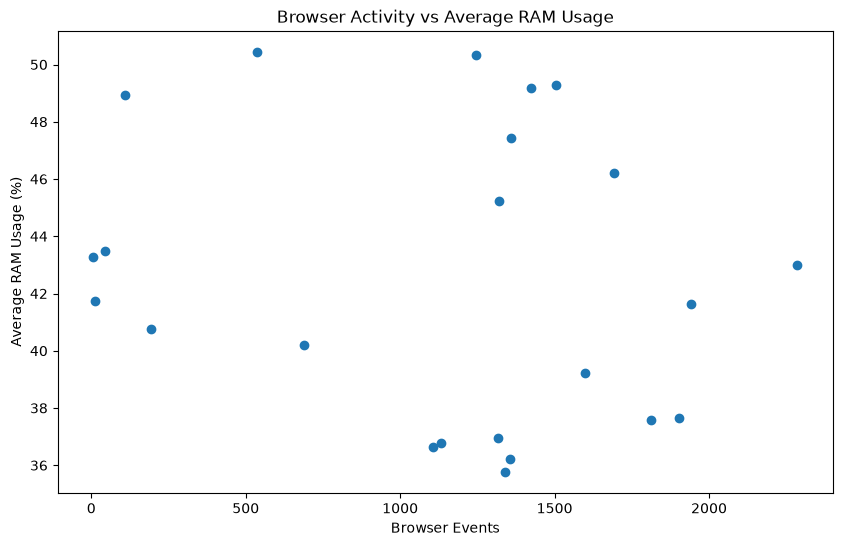

In [28]:
plt.figure(figsize=(10, 6))

plt.scatter(
    hourly_behavior["browser_events"],
    hourly_behavior["avg_ram_usage"],
)

plt.xlabel("Browser Events")
plt.ylabel("Average RAM Usage (%)")
plt.title("Browser Activity vs Average RAM Usage")

plt.show()

In [29]:
hourly_behavior[
    [
        "browser_events",
        "avg_ram_usage",
    ]
].corr()

,browser_events,avg_ram_usage
browser_events,1.000000,-0.174574
avg_ram_usage,-0.174574,1.000000


# Session Analysis

In [30]:
sessions = pd.read_parquet(paths["browser_sessions"])

session_stats = (
    sessions.groupby("session_id")
    .agg(
        session_start=("timestamp", "min"),
        session_end=("timestamp", "max"),
        event_count=("timestamp", "size"),
        unique_domains=("domain", "nunique"),
        unique_categories=("category", "nunique"),
        dominant_category=("category", lambda values: values.mode().iloc[0]),
    )
    .reset_index()
)

session_stats["duration_minutes"] = (
    session_stats["session_end"] - session_stats["session_start"]
).dt.total_seconds() / 60

session_stats["date"] = session_stats["session_start"].dt.date
session_stats["hour"] = session_stats["session_start"].dt.hour

print(f"Total sessions: {len(session_stats):,}")
session_stats.head()

Total sessions: 829


,session_id,session_start,session_end,event_count,unique_domains,unique_categories,dominant_category,duration_minutes,date,hour
0,1,2026-05-10 07:57:45.724093+00:00,2026-05-10 08:12:08.458927+00:00,19,2,2,Search/Reference,14.378914,2026-05-10,7
1,2,2026-05-10 08:34:14.826913+00:00,2026-05-10 08:57:13.046548+00:00,68,2,2,Social Media,22.970327,2026-05-10,8
2,3,2026-05-10 09:37:58.915377+00:00,2026-05-10 09:38:00.676474+00:00,2,2,2,Productivity/Work,0.029352,2026-05-10,9
3,4,2026-05-10 10:30:32.549173+00:00,2026-05-10 10:38:12.898864+00:00,26,3,3,Search/Reference,7.672495,2026-05-10,10
4,5,2026-05-10 10:54:24.152772+00:00,2026-05-10 12:17:26.390661+00:00,85,2,2,Social Media,83.037298,2026-05-10,10


In [31]:
session_stats[
    [
        "event_count",
        "unique_domains",
        "unique_categories",
        "duration_minutes",
    ]
].describe()

,event_count,unique_domains,unique_categories,duration_minutes
count,829.000000,829.000000,829.000000,829.000000
mean,31.262967,3.079614,2.094089,13.541659
std,53.577077,3.530534,1.340858,24.987400
min,1.000000,1.000000,1.000000,0.000000
25%,4.000000,1.000000,1.000000,0.462438
50%,13.000000,2.000000,2.000000,3.251542
75%,33.000000,4.000000,3.000000,16.222497
max,531.000000,49.000000,9.000000,209.491661


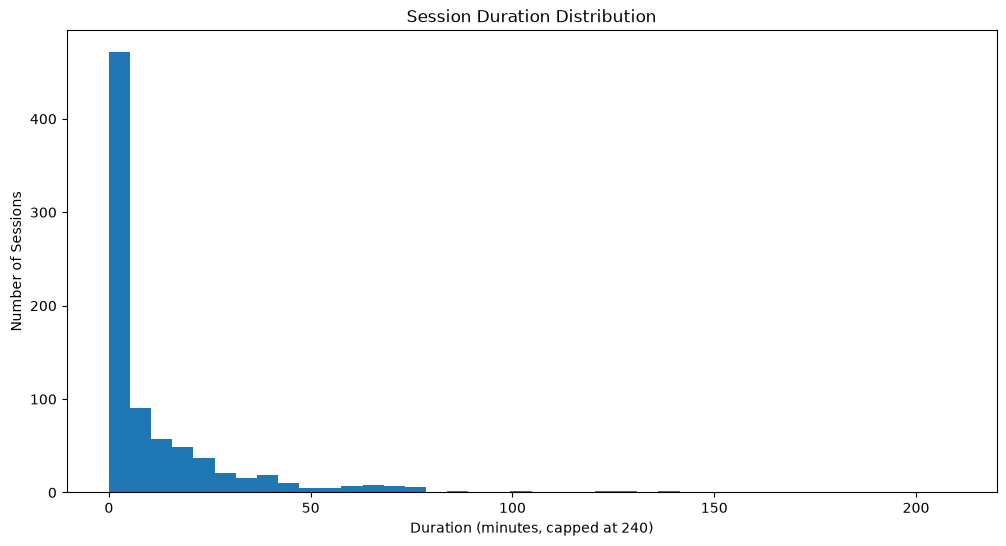

In [32]:
plt.figure(figsize=(12, 6))

session_stats["duration_minutes"].clip(upper=240).plot(
    kind="hist",
    bins=40,
)

plt.title("Session Duration Distribution")
plt.xlabel("Duration (minutes, capped at 240)")
plt.ylabel("Number of Sessions")

plt.show()

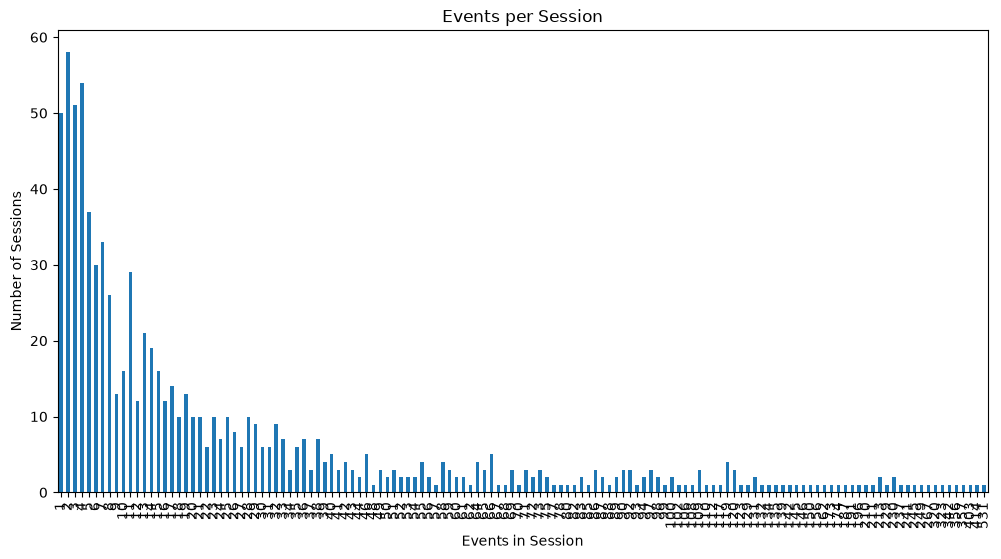

In [33]:
events_per_session = session_stats["event_count"].value_counts().sort_index()

plt.figure(figsize=(12, 6))

events_per_session.plot(kind="bar")

plt.title("Events per Session")
plt.xlabel("Events in Session")
plt.ylabel("Number of Sessions")

plt.show()

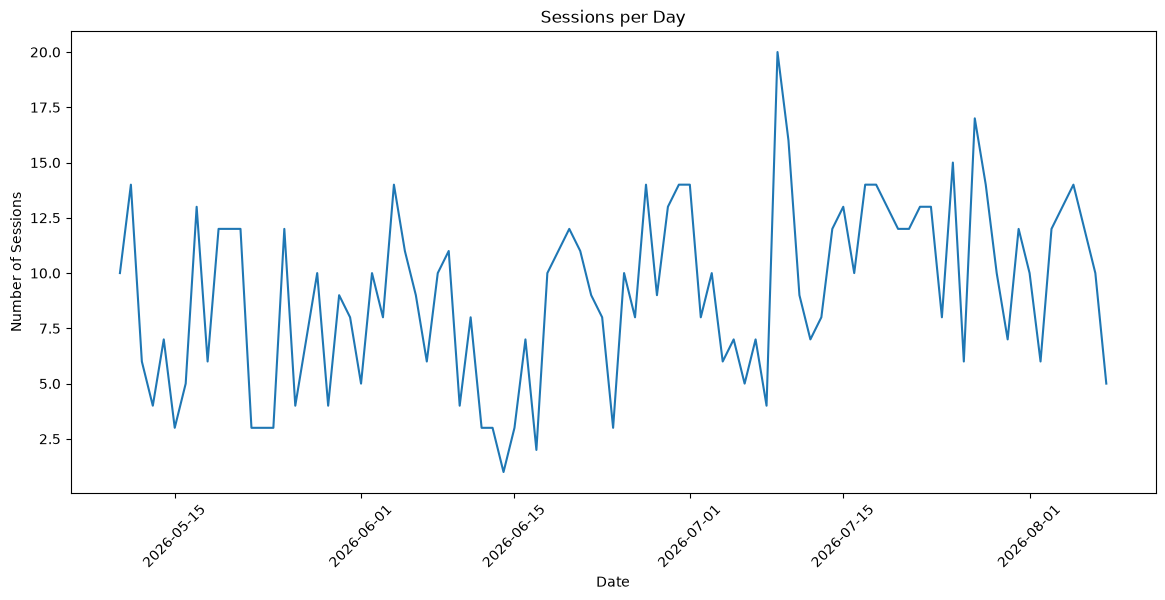

In [34]:
sessions_per_day = session_stats.groupby("date").size()

plt.figure(figsize=(14, 6))

sessions_per_day.plot()

plt.title("Sessions per Day")
plt.xlabel("Date")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)

plt.show()

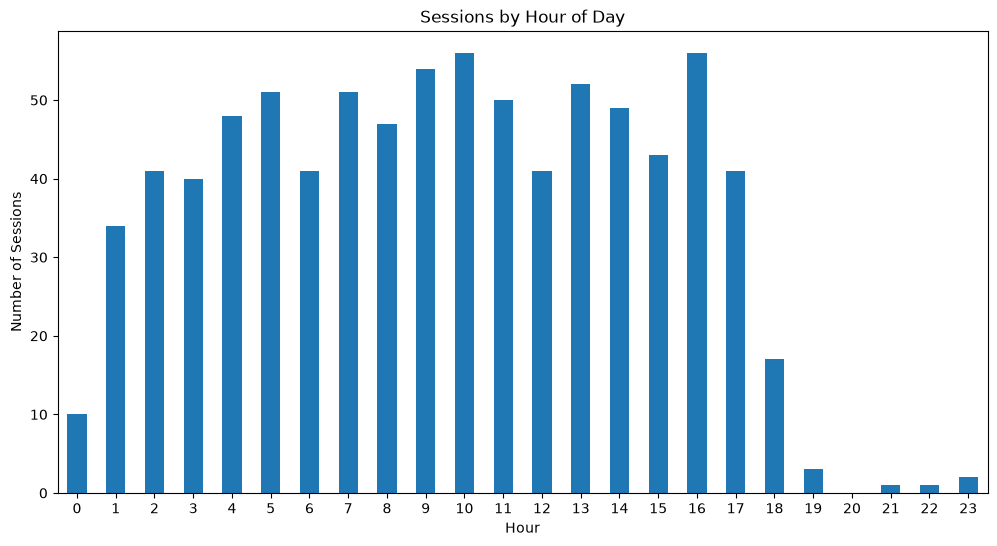

In [35]:
sessions_by_hour = session_stats["hour"].value_counts().reindex(range(24), fill_value=0)

sessions_by_hour.plot(kind="bar")

plt.title("Sessions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=0)

plt.show()

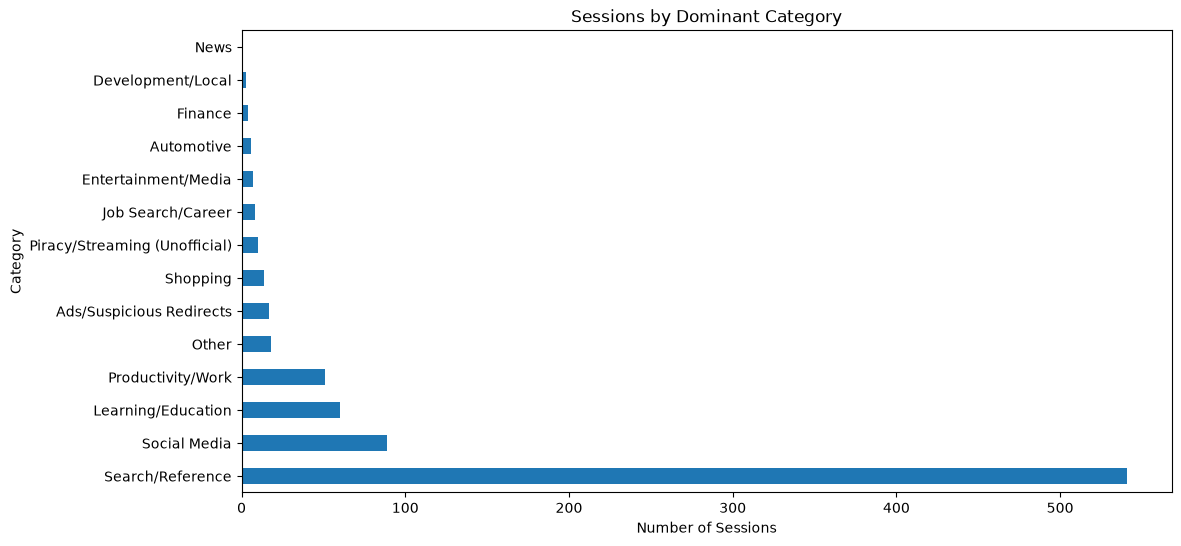

In [36]:
dominant_categories = session_stats["dominant_category"].value_counts()

dominant_categories.plot(kind="barh")

plt.title("Sessions by Dominant Category")
plt.xlabel("Number of Sessions")
plt.ylabel("Category")

plt.show()

# Data Quality

In [37]:
print(f"Exact duplicate rows: {events.duplicated().sum():,}")

print(f"Duplicate timestamp + URL events: {events.duplicated(subset=['timestamp', 'url']).sum():,}")

Exact duplicate rows: 52
Duplicate timestamp + URL events: 52


In [38]:
events = events.sort_values("timestamp").reset_index(drop=True)

events["time_gap_seconds"] = events["timestamp"].diff().dt.total_seconds()

events["time_gap_seconds"].describe()

count     25916.000000
mean        300.042187
std        2898.246340
min           0.000000
25%           0.588624
50%           3.810855
75%          14.787631
max      216546.091834
Name: time_gap_seconds, dtype: float64

In [39]:
largest_gaps = (
    events[
        [
            "timestamp",
            "domain",
            "time_gap_seconds",
        ]
    ]
    .sort_values(
        "time_gap_seconds",
        ascending=False,
    )
    .head(20)
)

largest_gaps

,timestamp,domain,time_gap_seconds
4905,2026-05-24 14:35:09.395223+00:00,www.google.com,216546.091834
8071,2026-06-15 04:36:53.724314+00:00,www.google.com,97453.493090
11368,2026-07-06 13:22:38.201125+00:00,www.google.com,74979.281155
1050,2026-05-14 06:37:11.346421+00:00,www.google.com,72031.905212
1286,2026-05-16 10:29:16.039143+00:00,www.google.com,71328.941893
8963,2026-06-24 04:22:21.227868+00:00,www.google.com,66781.153349
7297,2026-06-07 05:58:38.457230+00:00,www.google.com,63064.418410
7987,2026-06-12 08:25:40.405614+00:00,www.google.com,57125.133987
1663,2026-05-18 07:20:10.507648+00:00,www.shopsy.in,54233.218195
8191,2026-06-18 04:18:54.885325+00:00,www.google.com,52623.621336


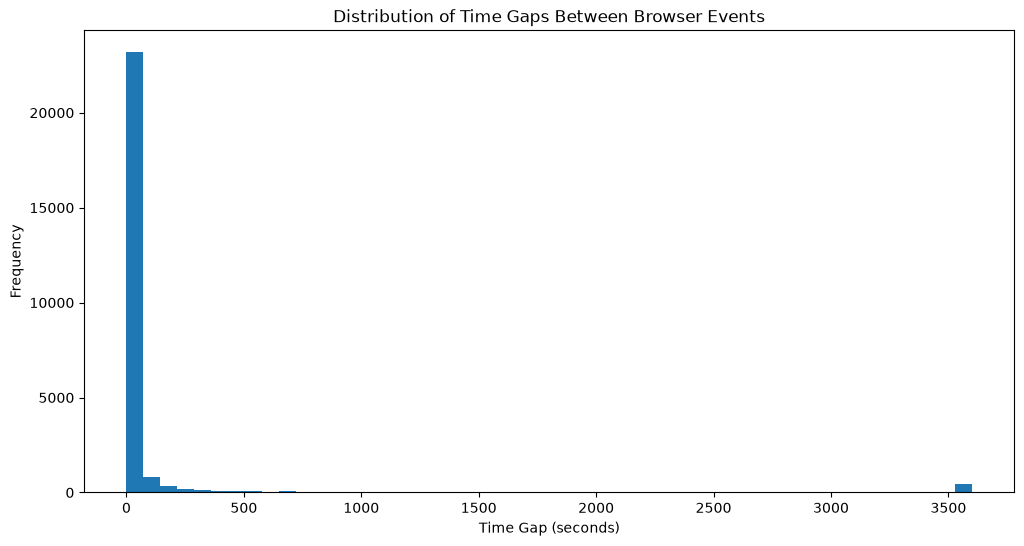

In [40]:
plt.figure(figsize=(12, 6))

events["time_gap_seconds"].dropna().clip(upper=3600).plot(
    kind="hist",
    bins=50,
)

plt.title("Distribution of Time Gaps Between Browser Events")
plt.xlabel("Time Gap (seconds)")
plt.ylabel("Frequency")

plt.show()

In [41]:
# Suspicious RAM values.
invalid_ram = events[(events["usage_percent"] < 0) | (events["usage_percent"] > 100)]

print(f"Invalid RAM usage records: {len(invalid_ram):,}")

Invalid RAM usage records: 0


In [42]:
# Memory accounting check: total = used + available (within tolerance).
events["memory_difference_mb"] = events["total_mb"] - events["used_mb"] - events["available_mb"]

events["memory_difference_mb"].describe()

suspicious_memory = events[events["memory_difference_mb"].abs() > 100]

print(f"Suspicious memory records: {len(suspicious_memory):,}")

Suspicious memory records: 0


In [43]:
print("Missing URLs:", events["url"].isna().sum())
print("Missing titles:", events["title"].isna().sum())
print("Missing domains:", events["domain"].isna().sum())

empty_urls = events["url"].astype(str).str.strip().eq("").sum()

print(f"Empty URLs: {empty_urls:,}")

Missing URLs: 0
Missing titles: 0
Missing domains: 1
Empty URLs: 0


In [44]:
# Outliers in RAM usage (IQR method).
q1 = events["usage_percent"].quantile(0.25)
q3 = events["usage_percent"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

ram_outliers = events[
    (events["usage_percent"] < lower_bound) | (events["usage_percent"] > upper_bound)
]

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Outliers: {len(ram_outliers):,}")

Q1: 37.12
Q3: 46.83
IQR: 9.71
Lower bound: 22.55
Upper bound: 61.39
Outliers: 38


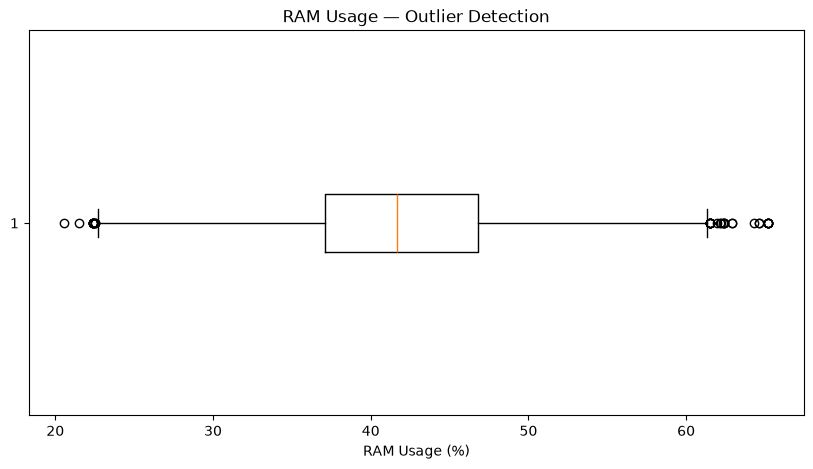

In [45]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    events["usage_percent"].dropna(),
    orientation="horizontal",
)

plt.title("RAM Usage — Outlier Detection")
plt.xlabel("RAM Usage (%)")

plt.show()

In [46]:
eda_summary = {
    "total_events": len(events),
    "unique_domains": events["domain"].nunique(),
    "unique_urls": events["url"].nunique(),
    "unique_categories": events["category"].nunique(),
    "total_sessions": len(session_stats),
    "avg_events_per_session": round(session_stats["event_count"].mean(), 2),
    "avg_session_duration_minutes": round(session_stats["duration_minutes"].mean(), 2),
    "duplicate_rows": int(events.duplicated().sum()),
    "duplicate_events": int(events.duplicated(subset=["timestamp", "url"]).sum()),
    "missing_domains": int(events["domain"].isna().sum()),
    "missing_urls": int(events["url"].isna().sum()),
    "mean_ram_usage": float(events["usage_percent"].mean()),
    "median_ram_usage": float(events["usage_percent"].median()),
    "max_ram_usage": float(events["usage_percent"].max()),
    "ram_outliers": len(ram_outliers),
}

pd.Series(eda_summary)

total_events                    25917.000000
unique_domains                    664.000000
unique_urls                     13267.000000
unique_categories                  17.000000
total_sessions                    829.000000
avg_events_per_session             31.260000
avg_session_duration_minutes       13.540000
duplicate_rows                     11.000000
duplicate_events                   52.000000
missing_domains                     1.000000
missing_urls                        0.000000
mean_ram_usage                     42.012783
median_ram_usage                   41.660000
max_ram_usage                      65.220000
ram_outliers                       38.000000
dtype: float64